In [ ]:
import torch
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import make_circles #Make circles is a binary classification dataset inbuilt in sklearn

#Creating Data for Classification

In [ ]:
n_samples = 1000
X,y = make_circles(n_samples,noise = 0.03 ,random_state=42)
X[:5],y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [ ]:
df = pd.DataFrame({'X1':X[:,0],'X2':X[:,1],'Label':y})
df

,X1,X2,Label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


In [ ]:
df['Label'].value_counts()

,count
Label,
1,500
0,500


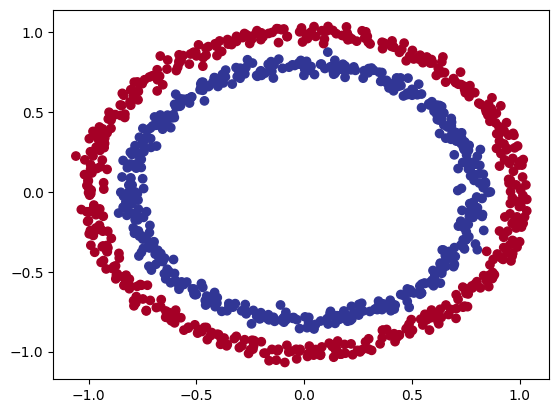

In [ ]:
plt.scatter(X[:,0],X[:,1],c = y , cmap = plt.cm.RdYlBu) #The data we are working with is classified in two categories Red and Blue (in this case)

In [ ]:
X.shape,y.shape

((1000, 2), (1000,))

Turning our data into Tensors

In [ ]:
type(X),type(y)
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
from sklearn.model_selection import train_test_split
#1. Device Agnostic Code # Not important in this case

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
len(X_train),len(y_test)
# X_train.to(device)
# X_test.to(device)
# y_train.to(device)
# y_test.to(device)

(800, 200)

#Building a model

Lets build a model to classify our Rd and blue dots
1. Set up a device agnostic code
2. Build a model by subclassing nn.Module
3. Defining loss function and an optimizer
4. Creating testing and training loops

In [ ]:
#2. Building a model
class Circle_Class(nn.Module):
  def __init__(self):
    super().__init__()
    #Creating layers for input and output data
    self.layer_01 = nn.Linear(in_features=2,out_features = 5) #Input Layer # the out_features of first till the in_features of the last layer form the main hidden layer of a neural network the more neurons there are in these layers the more our model will learn from the patterns in the input data
    self.layer_02 = nn.Linear(in_features=5,out_features = 1) #Output Layer # Out_features of the first and in features of the next layer must be the same to maintain the shape of the neurons in a neural network

  def forward(self,x):
    return self.layer_02(self.layer_01(x))

torch.manual_seed(42)
APC_Model = Circle_Class()
APC_Model.state_dict()


OrderedDict([('layer_01.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]])),
             ('layer_01.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410])),
             ('layer_02.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]])),
             ('layer_02.bias', tensor([-0.2060]))])

#or

In [ ]:
MODEL_01 = nn.Sequential(
          nn.Linear(in_features = 2, out_features = 5),
          nn.Linear(in_features = 5, out_features = 1)
).to(device)

MODEL_01.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]])),
             ('0.bias', tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370])),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]])),
             ('1.bias', tensor([-0.1213]))])

## Setting up a loss function and an optimizer

In [ ]:
Pretrain_Preds = MODEL_01(X_test.to(device))
print(f'Length of Preds = {len(Pretrain_Preds)} | Shape of Preds = {Pretrain_Preds.shape}')
print(f'Length of Test Samples = {len(y_test)} | Shape of Preds = {y_test.shape}')
print(f'| Untrained model Preds : {Pretrain_Preds[:10]} | Testing Data_Y : {y_test[:10]}')

Length of Preds = 200 | Shape of Preds = torch.Size([200, 1])
Length of Test Samples = 200 | Shape of Preds = torch.Size([200])
| Untrained model Preds : tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]], grad_fn=<SliceBackward0>) | Testing Data_Y : tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [ ]:
# nn.BCELoss() # requires input for sigmoid activation function prior to its own input
loss = nn.BCEWithLogitsLoss() # Comes with built in sigmoid activation function
optimizer = torch.optim.SGD(params = APC_Model.parameters(),lr = 0.1)

In [ ]:
def accuracy(koi_y,y_Preds):
  counter = torch.eq(koi_y,y_Preds).sum().item()
  acc = (counter/len(y_Preds))*100
  return acc

In [ ]:
y_Logits = MODEL_01(X_train.to(device))[:5] # Logits are basically raw output of the model we will further convert it into binary classes
y_Logits

tensor([[ 0.2826],
        [ 0.3236],
        [ 0.0202],
        [ 0.0421],
        [-0.0271]], grad_fn=<SliceBackward0>)

logits -> prediction probabilities -> prediction labels

The raw outputs (unmodified) of this equation ( y ) and in turn, the raw outputs of our model are often referred to as logits.

That's what our model is outputing above when it takes in the input data ( x  in the equation or X_test in the code), logits.

However, these numbers are hard to interpret.

We'd like some numbers that are comparable to our truth labels.

To get our model's raw outputs (logits) into such a form, we can use the sigmoid activation function.

Let's try it out.

In [ ]:
y_Preds_Probs = torch.sigmoid(y_Logits)
y_Preds_Probs

tensor([[0.5702],
        [0.5802],
        [0.5051],
        [0.5105],
        [0.4932]], grad_fn=<SigmoidBackward0>)

The closer to 0, the more the model thinks the sample belongs to class 0, the closer to 1, the more the model thinks the sample belongs to class 1.

More specificially:

If y_pred_probs >= 0.5, y=1 (class 1)
If y_pred_probs < 0.5, y=0 (class 0)
To turn our prediction probabilities into prediction labels, we can round the outputs of the sigmoid activation function.

In [ ]:
y_Preds = torch.round(y_Preds_Probs)
y_Preds.squeeze(),y_train[:5]

(tensor([1., 1., 1., 1., 0.], grad_fn=<SqueezeBackward0>),
 tensor([1., 0., 0., 0., 1.]))

Excellent! Now it looks like our model's predictions are in the same form as our truth labels (`y_test`).

#Training and Testing loops

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)


X_train,X_test = X_train.to(device),X_test.to(device)
y_train,y_test = y_train.to(device),y_test.to(device)

epochs = 1000
Training_Loss = []
epoch_count = []
Testing_Loss = []

for epoch in range(epochs):
  APC_Model.train()
  Train_Logits = APC_Model(X_train).squeeze()
  Train_Preds = torch.round(torch.sigmoid(Train_Logits))

  Train_loss = loss(Train_Logits,y_train)
  Train_Accuracy = accuracy(koi_y=y_train , y_Preds=Train_Preds)

  optimizer.zero_grad()
  Train_loss.backward()
  optimizer.step()

  APC_Model.eval()
  with torch.inference_mode():
    Test_Logits = APC_Model(X_test).squeeze()
    Test_Preds = torch.round(torch.sigmoid(Test_Logits))

    Test_loss = loss(Test_Logits,y_test)
    Test_Accuracy = accuracy(koi_y=y_test,y_Preds=Test_Preds)

  if epoch%10==0:
    print(f'Epochs = {epoch} | Training loss = {Train_loss:.5f} | Train_Accuracy = {Train_Accuracy:.2f}% | Testing loss = {Test_loss:.5f} | Test_Accuracy = {Test_Accuracy:.2f}%')


Epochs = 0 | Training loss = 0.69569 | Train_Accuracy = 50.00% | Testing loss = 0.69721 | Test_Accuracy = 50.00%
Epochs = 10 | Training loss = 0.69403 | Train_Accuracy = 50.00% | Testing loss = 0.69615 | Test_Accuracy = 50.00%
Epochs = 20 | Training loss = 0.69343 | Train_Accuracy = 46.00% | Testing loss = 0.69585 | Test_Accuracy = 48.50%
Epochs = 30 | Training loss = 0.69321 | Train_Accuracy = 49.00% | Testing loss = 0.69577 | Test_Accuracy = 47.50%
Epochs = 40 | Training loss = 0.69312 | Train_Accuracy = 49.50% | Testing loss = 0.69573 | Test_Accuracy = 46.50%
Epochs = 50 | Training loss = 0.69308 | Train_Accuracy = 50.38% | Testing loss = 0.69569 | Test_Accuracy = 46.50%
Epochs = 60 | Training loss = 0.69306 | Train_Accuracy = 50.50% | Testing loss = 0.69564 | Test_Accuracy = 46.50%
Epochs = 70 | Training loss = 0.69305 | Train_Accuracy = 50.50% | Testing loss = 0.69559 | Test_Accuracy = 46.50%
Epochs = 80 | Training loss = 0.69304 | Train_Accuracy = 50.75% | Testing loss = 0.69553 

In [ ]:
with torch.inference_mode():
  Predictions = MODEL_01(X_test)
Predictions[:10],y_test[:10]

(tensor([[-0.0338],
         [-0.0309],
         [ 0.0894],
         [-0.0692],
         [ 0.2967],
         [ 0.2968],
         [ 0.1405],
         [ 0.2178],
         [ 0.0805],
         [-0.0284]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

For Further improvement

Hmm, what do you notice about the performance of our model?

It looks like it went through the training and testing steps fine but the results don't seem to have moved too much.

The accuracy barely moves above 50% on each data split.

And because we're working with a balanced binary classification problem, it means our model is performing as good as random guessing (with 500 samples of class 0 and class 1 a model predicting class 1 every single time would achieve 50% accuracy).

4. Make predictions and evaluate the model
From the metrics it looks like our model is random guessing.

How could we investigate this further?

I've got an idea.

The data explorer's motto!

"Visualize, visualize, visualize!"

Let's make a plot of our model's predictions, the data it's trying to predict on and the decision boundary it's creating for whether something is class 0 or class 1.

To do so, we'll write some code to download and import the helper_functions.py script from the Learn PyTorch for Deep Learning repo.

It contains a helpful function called plot_decision_boundary() which creates a NumPy meshgrid to visually plot the different points where our model is predicting certain classes.

We'll also import plot_predictions() which we wrote in notebook 01 to use later.

In [ ]:
import requests
from pathlib import Path

In [ ]:
if Path('helper_functions.py').is_file():
  print('Already exist ,skip download')
else:
  print('Downloading helper_function.py')
  request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py')
  with open('helper_functions.py','wb') as file:
    file.write(request.content)

Already exist ,skip download


In [ ]:
from helper_functions import plot_decision_boundary,plot_predictions

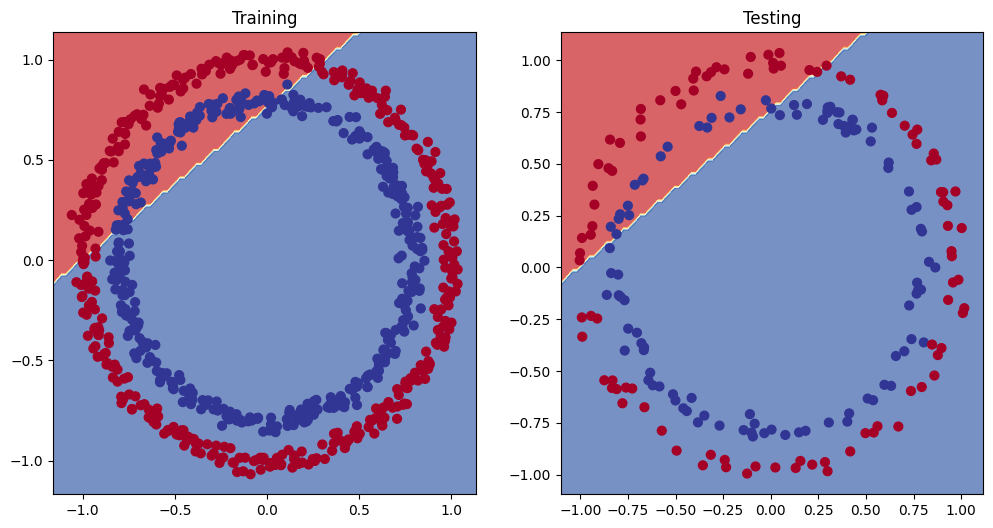

In [ ]:
plt.figure(figsize = (12,6) )
plt.subplot(1,2,1)
plt.title('Training')
plot_decision_boundary(MODEL_01,X_train,y_train)
plt.subplot(1,2,2)
plt.title('Testing')
plot_decision_boundary(MODEL_01,X_test,y_test)


5. Improving a model (from a model perspective)
Let's try to fix our model's underfitting problem.

Focusing specifically on the model (not the data), there are a few ways we could do this.

Model improvement technique*	What does it do?
Add more layers	Each layer potentially increases the learning capabilities of the model with each layer being able to learn some kind of new pattern in the data. More layers are often referred to as making your neural network deeper.
Add more hidden units	Similar to the above, more hidden units per layer means a potential increase in learning capabilities of the model. More hidden units are often referred to as making your neural network wider.
Fitting for longer (more epochs)	Your model might learn more if it had more opportunities to look at the data.
Changing the activation functions	Some data just can't be fit with only straight lines (like what we've seen), using non-linear activation functions can help with this (hint, hint).
Change the learning rate	Less model specific, but still related, the learning rate of the optimizer decides how much a model should change its parameters each step, too much and the model overcorrects, too little and it doesn't learn enough.
Change the loss function	Again, less model specific but still important, different problems require different loss functions. For example, a binary cross entropy loss function won't work with a multi-class classification problem.
Use transfer learning	Take a pretrained model from a problem domain similar to yours and adjust it to your own problem. We cover transfer learning in notebook 06.
Note: because you can adjust all of these by hand, they're referred to as *hyperparameters**.

And this is also where machine learning's half art half science comes in, there's no real way to know here what the best combination of values is for your project, best to follow the data scientist's motto of "experiment, experiment, experiment".

Let's see what happens if we add an extra layer to our model, fit for longer (epochs=1000 instead of epochs=100) and increase the number of hidden units from 5 to 10.

We'll follow the same steps we did above but with a few changed hyperparameters.

| Model improvement technique* | What does it do? |
| ----- | ----- |
| **Add more layers** | Each layer *potentially* increases the learning capabilities of the model with each layer being able to learn some kind of new pattern in the data. More layers are often referred to as making your neural network *deeper*. |
| **Add more hidden units** | Similar to the above, more hidden units per layer means a *potential* increase in learning capabilities of the model. More hidden units are often referred to as making your neural network *wider*. |
| **Fitting for longer (more epochs)** | Your model might learn more if it had more opportunities to look at the data. |
| **Changing the activation functions** | Some data just can't be fit with only straight lines (like what we've seen), using non-linear activation functions can help with this (hint, hint). |
| **Change the learning rate** | Less model specific, but still related, the learning rate of the optimizer decides how much a model should change its parameters each step, too much and the model overcorrects, too little and it doesn't learn enough. |
| **Change the loss function** | Again, less model specific but still important, different problems require different loss functions. For example, a binary cross entropy loss function won't work with a multi-class classification problem. |
| **Use transfer learning** | Take a pretrained model from a problem domain similar to yours and adjust it to your own problem. We cover transfer learning in [notebook 06](https://www.learnpytorch.io/06_pytorch_transfer_learning/). |

In [ ]:
class MODEL_02(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_01 = nn.Linear(in_features=2 , out_features= 10)
    self.layer_02 = nn.Linear(in_features= 10, out_features= 10 )
    self.layer_03 = nn.Linear(in_features= 10 , out_features= 1)

  def forward(self , x):
    return self.layer_03(self.layer_02(self.layer_01(x)))

model_02 = MODEL_02()
model_02

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
Optimizer = torch.optim.Adam(params = model_02.parameters(),lr =0.1)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs = 1000

X_train,y_train,X_test,y_test = X_train.to(device),y_train.to(device),X_test.to(device),y_test.to(device)

for epoch in range(epochs):
  model_02.train()
  Train_logits = model_02(X_train).squeeze()
  Train_preds = torch.round(torch.sigmoid(Train_logits))

  Train_Loss = loss_fn(Train_logits,y_train)
  Train_accuracy = accuracy(y_train,Train_preds)

  Optimizer.zero_grad()
  Train_Loss.backward()
  Optimizer.step()

  model_02.eval()
  with torch.inference_mode():
    Test_logits = model_02(X_test).squeeze()
    Test_preds = torch.round(torch.sigmoid(Test_logits))

    Test_Loss = loss_fn(Test_logits,y_test)
    Test_accuracy = accuracy(y_test,Test_preds)

  if epoch%100==0:
    print(f'Epochs = {epoch} | Training loss = {Train_Loss:.5f} | Train_Accuracy = {Train_accuracy:.2f}% | Testing loss = {Test_Loss:.5f} | Test_Accuracy = {Test_accuracy:.2f}%')

Epochs = 0 | Training loss = 0.69295 | Train_Accuracy = 50.00% | Testing loss = 0.69394 | Test_Accuracy = 50.00%
Epochs = 100 | Training loss = 0.00168 | Train_Accuracy = 100.00% | Testing loss = 0.00744 | Test_Accuracy = 100.00%
Epochs = 200 | Training loss = 0.00071 | Train_Accuracy = 100.00% | Testing loss = 0.00543 | Test_Accuracy = 100.00%
Epochs = 300 | Training loss = 0.00041 | Train_Accuracy = 100.00% | Testing loss = 0.00493 | Test_Accuracy = 100.00%
Epochs = 400 | Training loss = 0.00026 | Train_Accuracy = 100.00% | Testing loss = 0.00573 | Test_Accuracy = 100.00%
Epochs = 500 | Training loss = 0.00018 | Train_Accuracy = 100.00% | Testing loss = 0.00516 | Test_Accuracy = 100.00%
Epochs = 600 | Training loss = 0.00013 | Train_Accuracy = 100.00% | Testing loss = 0.00513 | Test_Accuracy = 100.00%
Epochs = 700 | Training loss = 0.00010 | Train_Accuracy = 100.00% | Testing loss = 0.00534 | Test_Accuracy = 100.00%
Epochs = 800 | Training loss = 0.00008 | Train_Accuracy = 100.00% | 

### 5.1 Preparing data to see if our model can model a straight line
Let's create some linear data to see if our model's able to model it and we're not just using a model that can't learn anything.

In [ ]:
# Create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias # linear regression formula

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [ ]:
# Create train and test splits
train_split = int(0.8 * len(X_regression)) # 80% of data used for training set
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the lengths of each split
print(len(X_train_regression),
    len(y_train_regression),
    len(X_test_regression),
    len(y_test_regression))

80 80 20 20


In [ ]:
model_2 = nn.Sequential(

    nn.Linear(in_features=1,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10,out_features=1)

).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
losss = nn.L1Loss()
Optim = torch.optim.SGD(params = model_2.parameters(),lr = 0.01)

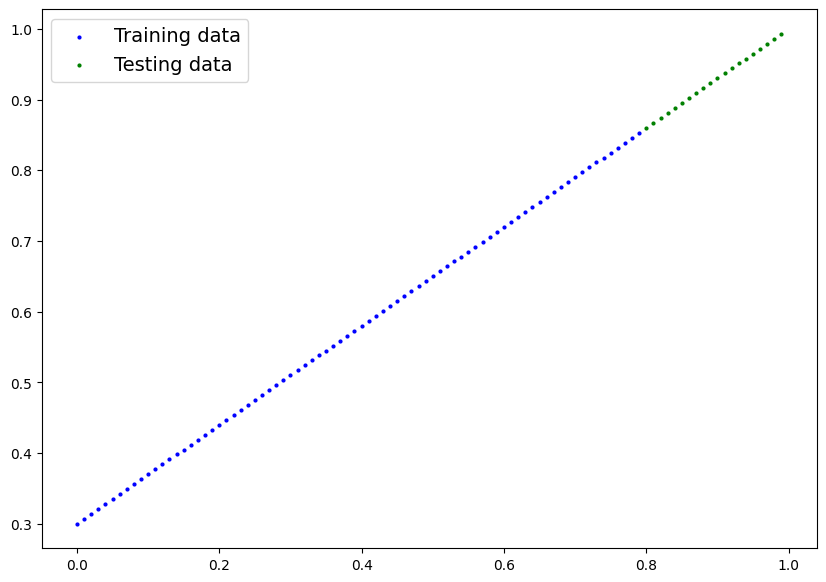

In [ ]:
plot_predictions(train_data=X_train_regression,
    train_labels=y_train_regression,
    test_data=X_test_regression,
    test_labels=y_test_regression
);

In [ ]:
epo = 1000
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epo):
  model_2.train()
  Train_Pred = model_2(X_train_regression)
  Train_Los = losss(Train_Pred,y_train_regression)

  Optim.zero_grad()
  Train_Los.backward()
  Optim.step()

  model_2.eval()
  with torch.inference_mode():
    Test_Pred = model_2(X_test_regression)
    Test_Los = losss(Test_Pred,y_test_regression)

  if epoch%100==0:
    print(f'Epochs = {epoch} / Training loss = {Train_Los} / Testing loss = {Test_Los}')



Epochs = 0 / Training loss = 0.05050472542643547 / Testing loss = 0.10412152856588364
Epochs = 100 / Training loss = 0.008538414724171162 / Testing loss = 0.00042653977288864553
Epochs = 200 / Training loss = 0.006430210079997778 / Testing loss = 0.0014719307655468583
Epochs = 300 / Training loss = 0.006428561173379421 / Testing loss = 0.001232728362083435
Epochs = 400 / Training loss = 0.006125602405518293 / Testing loss = 0.0008880436653271317
Epochs = 500 / Training loss = 0.0064448402263224125 / Testing loss = 0.0013517886400222778
Epochs = 600 / Training loss = 0.00644361088052392 / Testing loss = 0.0009624272352084517
Epochs = 700 / Training loss = 0.006460974924266338 / Testing loss = 0.0014480709796771407
Epochs = 800 / Training loss = 0.006160449236631393 / Testing loss = 0.0010231196647509933
Epochs = 900 / Training loss = 0.006476955022662878 / Testing loss = 0.001516443444415927


Okay, unlike `model_1` on the classification data, it looks like `model_2`'s loss is actually going down.

Let's plot its predictions to see if that's so.

And remember, since our model and data are using the target `device`, and this device may be a GPU, however, our plotting function uses matplotlib and matplotlib can't handle data on the GPU.

To handle that, we'll send all of our data to the CPU using [`.cpu()`](https://pytorch.org/docs/stable/generated/torch.Tensor.cpu.html) when we pass it to `plot_predictions()`.

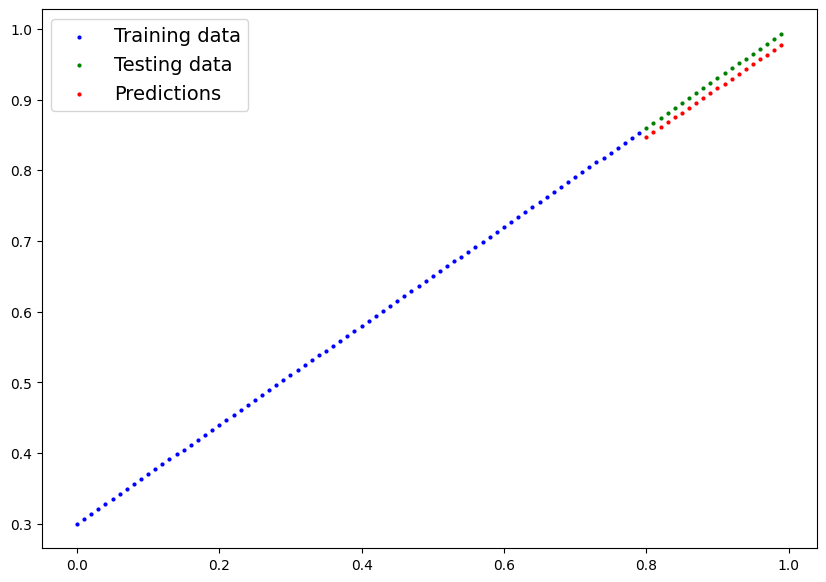

In [ ]:
# Turn on evaluation mode
model_2.eval()

# Make predictions (inference)
with torch.inference_mode():
    y_preds = model_2(X_test_regression)

# Plot data and predictions with data on the CPU (matplotlib can't handle data on the GPU)
# (try removing .cpu() from one of the below and see what happens)
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression,
                 predictions=y_preds);